# 03. Reproducibility across screens and cell lines (Fig. S4A-F)

Three screens are compared: K562 genome-wide (day 8), K562 essential (day 6) and RPE1 essential (day 7).
Following the Fig. S4 legend:

- **S4A/C**: perturbations with >10 differentially expressed genes in all three screens; perturbation-perturbation
  correlations computed over the same well-expressed (>0.25 UMI/cell), highly variable genes in each screen, then
  compared between screens (the paper reports the cophenetic correlation, r = 0.82 for the two K562 screens and
  0.37 for K562 vs RPE1; here the Pearson correlation of the two sets of pairwise correlations is used);
- **S4B**: for perturbations with >10 DEGs in both screens of a pair, the correlation of the same perturbation's
  profile between screens over well-expressed (>0.5 UMI/cell) genes (paper medians 0.50 and 0.23);
- **S4D/E**: KEGG enrichment of perturbations that agree (r > 0.5) or disagree (r < 0) between K562 and RPE1;
- **S4F**: correlation of ribosome-related perturbations in K562 essential.

In [1]:
import sys; sys.path.insert(0, "../src")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import gwps

screens = {"K562 genome-wide": gwps.load("k562_gw"), "K562 essential": gwps.load("k562_ess"), "RPE1": gwps.load("rpe1")}
# perturbation IDs ('<library number>_<gene>_<sgRNA pair>_<Ensembl ID>') are shared between screens

def responsive(a):
    return set(a.obs_names[(a.obs["anderson_darling_counts"] > 10) & ~a.obs["is_control"]])

common_genes = set.intersection(*(set(a.var_names) for a in screens.values()))
shared = sorted(set.intersection(*(responsive(a) for a in screens.values())))
print(f"{len(shared)} perturbations with >10 DEGs in all three screens (paper: 1,206); {len(common_genes)} shared genes")

1205 perturbations with >10 DEGs in all three screens (paper: 1,206); 7079 shared genes


## Report Fig. 5 (left, middle): perturbation-perturbation correlations agree between screens (cf. paper Fig. S4A, S4C)

1066 genes used
K562 essential vs K562 genome-wide: r = 0.83


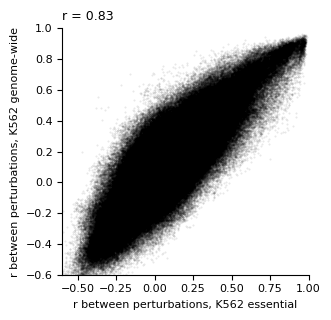

K562 essential vs RPE1: r = 0.33


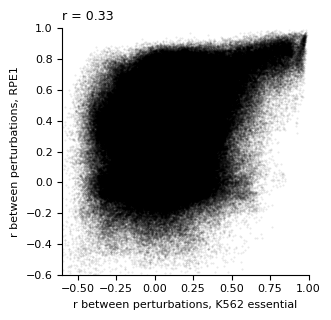

In [2]:
def hv_genes(a, genes):
    v = a.var.loc[sorted(genes)]
    well = v[v["mean"] > 0.25]
    return set(well.index[well["std"] >= well["std"].quantile(0.7)])

# same gene set in every screen: well-expressed and highly variable in all three
genes = sorted(set.intersection(*(hv_genes(a, common_genes) for a in screens.values())))
pair_r = {name: gwps.corr_upper(np.corrcoef(gwps.profiles(a[shared], genes).values)) for name, a in screens.items()}
print(f"{len(genes)} genes used")

for other, name in [("K562 genome-wide", "fig05a_k562_screens"), ("RPE1", "fig05b_k562_rpe1")]:
    x, y = pair_r["K562 essential"], pair_r[other]
    r = np.corrcoef(x, y)[0, 1]
    print(f"K562 essential vs {other}: r = {r:.2f}")
    fig, ax = plt.subplots(figsize=(3.2, 3.2))
    ax.scatter(x, y, s=0.2, c="black", alpha=0.1, rasterized=True)
    ax.set_xlim(-0.6, 1); ax.set_ylim(-0.6, 1); ax.set_aspect("equal")
    ax.set_xlabel("r between perturbations, K562 essential"); ax.set_ylabel(f"r between perturbations, {other}")
    ax.set_title(f"r = {r:.2f}", loc="left")
    gwps.savefig(fig, name)

## Report Fig. 5 (right): correlation of the same perturbation between screens (cf. paper Fig. S4B)

median r: K562 essential vs genome-wide 0.60 (n=1249); K562 vs RPE1 0.33 (n=1323)


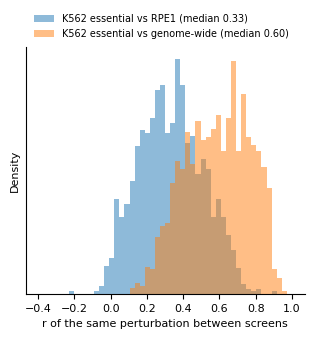

In [3]:
def same_perturbation_r(a, b):
    keys = sorted(responsive(a) & responsive(b))
    g = sorted(set(a.var_names[a.var["mean"] > 0.5]) & set(b.var_names[b.var["mean"] > 0.5]))
    A, B = gwps.profiles(a[keys], g).values, gwps.profiles(b[keys], g).values
    A, B = gwps.standardize_rows(A), gwps.standardize_rows(B)
    return pd.Series((A * B).mean(1), index=keys)

r_k562 = same_perturbation_r(screens["K562 essential"], screens["K562 genome-wide"])
r_cell = same_perturbation_r(screens["K562 essential"], screens["RPE1"])
print(f"median r: K562 essential vs genome-wide {r_k562.median():.2f} (n={len(r_k562)}); "
      f"K562 vs RPE1 {r_cell.median():.2f} (n={len(r_cell)})")

fig, ax = plt.subplots(figsize=(3.6, 3.2))
ax.hist(r_cell, bins=50, range=(-0.4, 1), alpha=0.5, density=True, label=f"K562 essential vs RPE1 (median {r_cell.median():.2f})")
ax.hist(r_k562, bins=50, range=(-0.4, 1), alpha=0.5, density=True, label=f"K562 essential vs genome-wide (median {r_k562.median():.2f})")
ax.set_xlabel("r of the same perturbation between screens"); ax.set_ylabel("Density"); ax.set_yticks([])
ax.legend(frameon=False, loc="lower left", bbox_to_anchor=(0, 1.0))
gwps.savefig(fig, "fig05c_same_perturbation")

## Report Fig. 6: which perturbations agree between K562 and RPE1? (cf. paper Fig. S4D, S4E)

Background: all perturbations entering the K562-RPE1 comparison.

r > 0.5: 250 perturbations, 2 KEGG terms; r < 0: 19 perturbations, 1 KEGG terms


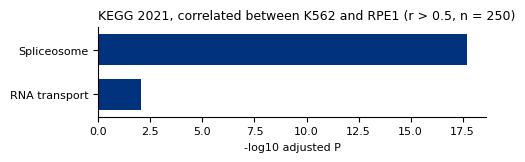

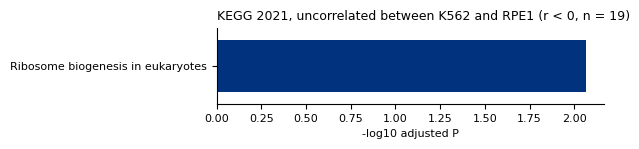

r < 0: ['ACTR10', 'AP2S1', 'ARID3A', 'ARIH1', 'COPE', 'DNMT1', 'ENO1', 'KCMF1', 'KCTD10', 'OSTC', 'PGD', 'POP1', 'PWP2', 'RPP38', 'RPP40', 'RTEL1', 'UBE2D3', 'UTP3', 'UTP6']


,Term,Odds Ratio,Adjusted P-value,Genes
0,Ribosome biogenesis in eukaryotes,10.178571,0.00865,UTP6;POP1;RPP40;PWP2;RPP38


In [4]:
tgt = lambda keys: pd.Index(keys).str.split("_").str[1].unique()
background = tgt(r_cell.index)
enr_agree = gwps.enrich(tgt(r_cell.index[r_cell > 0.5]), background)
enr_disagree = gwps.enrich(tgt(r_cell.index[r_cell < 0]), background)
print(f"r > 0.5: {(r_cell > 0.5).sum()} perturbations, {len(enr_agree)} KEGG terms; "
      f"r < 0: {(r_cell < 0).sum()} perturbations, {len(enr_disagree)} KEGG terms")
gwps.enrich_barplot(enr_agree, f"KEGG 2021, correlated between K562 and RPE1 (r > 0.5, n = {(r_cell > 0.5).sum()})", "fig06a_kegg_agree")
gwps.enrich_barplot(enr_disagree, f"KEGG 2021, uncorrelated between K562 and RPE1 (r < 0, n = {(r_cell < 0).sum()})", "fig06b_kegg_disagree")
print("r < 0:", sorted(tgt(r_cell.index[r_cell < 0])))
enr_disagree[["Term", "Odds Ratio", "Adjusted P-value", "Genes"]]

## Report Fig. 7: ribosomal subunits, biogenesis factors and poorly characterized genes, K562 essential (cf. paper Fig. S4F)

Genes shown in the paper's Fig. S4F; ordered by average-linkage clustering on Euclidean distance.

21 strong perturbations; genes without a strong perturbation in the essential screen: ['C1orf131', 'SPATA5L1', 'SPOUT1', 'UTP11']


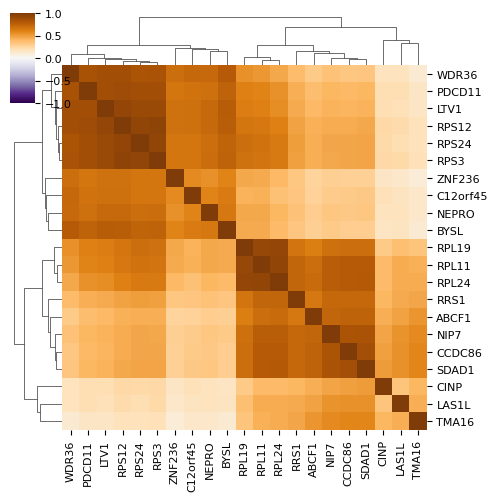

In [5]:
# NOPCHAP1 is listed under its former symbol C12orf45 in the data
ribo = ["BYSL", "C1orf131", "C12orf45", "WDR36", "LTV1", "PDCD11", "RPS24", "RPS12", "RPS3", "NEPRO",
        "ZNF236", "UTP11", "RPL11", "RPL19", "ABCF1", "NIP7", "RRS1", "SDAD1", "CCDC86", "RPL24", "LAS1L",
        "SPATA5L1", "TMA16", "SPOUT1", "CINP"]
ess = screens["K562 essential"]
strong_ess = gwps.classify(ess.obs) == "strong"
sel = ess.obs_names[ess.obs["target"].isin(ribo) & strong_ess]
prof = gwps.profiles(ess[sel], ess.var_names[ess.var["mean"] > 0.25])
t_ = ess.obs.loc[sel, "target"]
# genes with more than one strong sgRNA pair are labelled with the library number of the pair
prof.index = [f"{g} ({i.split('_')[0]})" if (t_ == g).sum() > 1 else g for i, g in zip(sel, t_)]
missing = sorted(set(ribo) - set(t_))
print(f"{prof.shape[0]} strong perturbations; genes without a strong perturbation in the essential screen: {missing}")
g = sns.clustermap(pd.DataFrame(np.corrcoef(prof.values), index=prof.index, columns=prof.index), method="average",
                   metric="euclidean", cmap=gwps.CORR_CMAP, vmin=-1, vmax=1, figsize=(5, 5), dendrogram_ratio=0.12,
                   xticklabels=True, yticklabels=True)
gwps.savefig(g.fig, "fig07_ribosome_biogenesis")